Contenido bajo licencia Creative Commons BY 4.0 y código bajo licencia MIT. © Nicolás Guarín-Zapata 2026.

# Método de residuos ponderados para valores propios

## Problema a resolver

Consideremos la siguiente ecuación diferencial

$$\frac{d^2u}{dx^2} + k^2 u= 0 \enspace , $$

con condiciones de frontera $u(0)=u(1)=0$.

La solución a este problema de valores propios son los
pares

$$u^{(n)}_e(x) = \sin(n\pi x)\,,\quad k_n = n\pi \, ,$$

## Aproximación propuesta

Propongamos una aproximación a la solución de la siguiente forma

$$u_N(x) = \sum_{i=0}^N c_i \phi_i(x) = x (1-x) \sum_{i=0}^N c_i x^i\, ,$$

en donde vemos que esta función satisface las condiciones de frontera.

Y el residual estaría dado por

$$R = \frac{d^2 u_N}{dx^2} + k^2 u_N\, .$$

## Residuos ponderados

En el método de residuos ponderados se busca que el _promedio_ ponderado
del residual sea cero, es decir

$$\int\limits_\Omega R w_i \mathrm{d}\Omega = 0\quad \forall w_i\, .$$

Que en este caso, podemos reescribir como


$$-\int\limits_\Omega \frac{d^2 u_N}{dx^2} w_i \mathrm{d}\Omega = k^2\int\limits_\Omega u_N w_i \mathrm{d}\Omega\quad \forall w_i\, .$$

## Funciones auxiliares

In [1]:
if 'google.colab' in str(get_ipython()):
    %pip install ipympl
    from google.colab import output
    output.enable_custom_widget_manager()

In [2]:
%matplotlib notebook

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import *

In [4]:
init_printing()

# Configuracion graficos
gris = '#757575'
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["text.color"] = gris
plt.rcParams["font.size"] = 12
plt.rcParams["xtick.color"] = gris
plt.rcParams["ytick.color"] = gris
plt.rcParams["axes.labelcolor"] = gris
plt.rcParams["axes.edgecolor"] = gris
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

In [5]:
x = symbols('x')

In [6]:
u_e = lambda n, x: sin(n*pi*x)

In [7]:
def plot_expr(expr, x, rango=(0, 1), ax=None, linestyle="solid"):
    """Grafica expresiones de SymPy que dependen de una variable"""
    expr_num = lambdify(x, expr, "numpy")
    x0 = rango[0]
    x1 = rango[1]
    x_num = np.linspace(0, 1, 301)
    if ax is None:
        plt.figure()
        ax = plt.gca()
    ax.plot(x_num, expr_num(x_num), linestyle=linestyle)

Creemos algunas funciones que nos serán útiles.

In [8]:
def funcion_base(x, k):
    """Elemento k de la base"""
    return x*(1 - x)*x**k


def funcion_aprox(x, num):
    """Función de aproximación
    
    Parametros
    ----------
    num : int
        Número de términos en la expansión.
        
    Devuelve
    -------_
    u_n : expresiónd de SymPy
        Función de aproximación.
    c : lista
        Lista de coeficientes.
        
    """    
    c = symbols('c0:%d'%num)
    u_n = sum([c[k]*funcion_base(x, k) for k in range(num)])
    return u_n, c


def residual(u, x, k):
    """Residual para el problema de interés"""
    return diff(u, x, 2) + k**2*u

Si usamos una función de aproximación con 2 términos tendríamos

In [9]:
nterms = 7

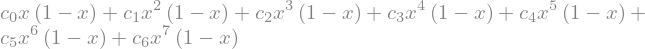

In [10]:
u, c = funcion_aprox(x, nterms)
u

Y el residual sería

In [11]:
k = symbols("k")

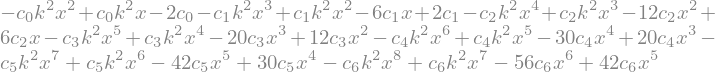

In [12]:
res = expand(residual(u, x, k))
factor(res)

## Método de Galerkin

En este caso tendríamos

$$-\int\limits_\Omega \frac{d^2 u_N}{dx^2} \phi_k \mathrm{d}\Omega = k^2\int\limits_\Omega u_N \phi_k \mathrm{d}\Omega\quad \forall \phi_k\, .$$

En este caso tendríamos las siguientes ecuaciones:

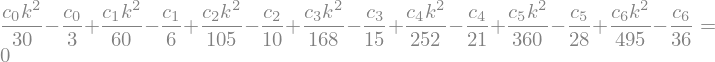

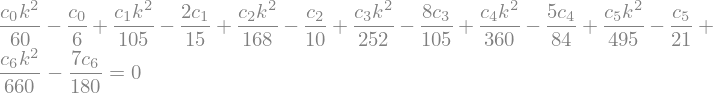

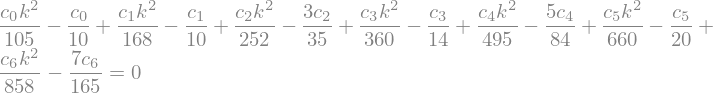

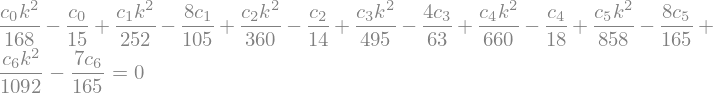

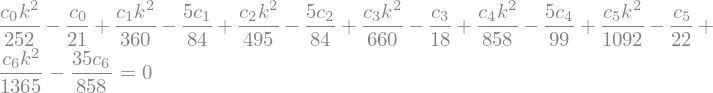

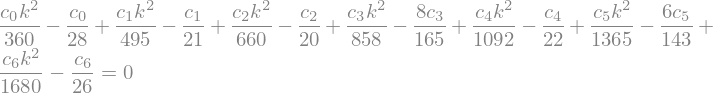

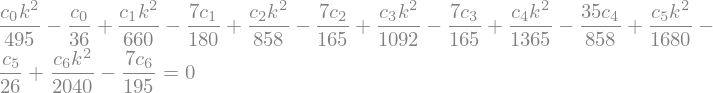

In [13]:
eqs_gale = []
for cont in range(nterms):
    eqs_gale.append(Eq(integrate(res*funcion_base(x, cont), (x, 0, 1)), 0))
    display(eqs_gale[cont])

Como queremos resolver un problema de valores propios, no
nos interesa encontrar un vector solución. Esto es porque
ya sabemos que el vector nulo es solución.

En este caso, nos interesa que la matriz formada por el sistema
tenga determinante nulo.

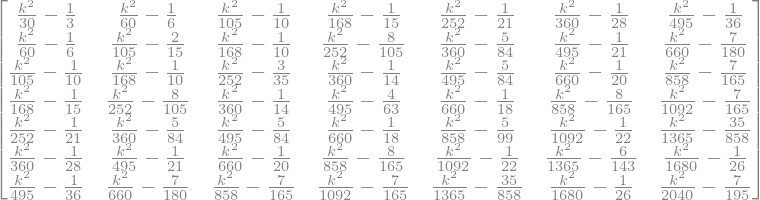

In [14]:
mat_gale =Matrix(nterms, nterms, lambda i, j: diff((eqs_gale[i]).lhs, c[j]))
mat_gale

In [15]:
vals_gale = solve(det(mat_gale), k**2)

Y la aproximación sería entonces

In [16]:
sorted([re(N(sqrt(val), 4)) for val in vals_gale])

Podemos comparar con la solución analítica para los primeros
valores propios. El método de Galerkin para este problema
nos debe dar una cota superior para los valores propios
exactos. Es decir, que todos deben estar por encima (o ser iguales)
de su valor propio correspondiente.

In [17]:
[N(k * pi, 4) for k in range(1, nterms + 1)]

## Colocación

En este caso, tendríamos

$$-\frac{d^2 u_N}{dx^2}(x_i) = k^2 u_N(x_i)\quad \forall x_i\, .$$

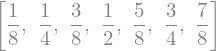

In [18]:
x_colo = [(cont + 1)*S(1)/(nterms + 1) for cont in range(nterms)]
x_colo

In [19]:
eqs_colo = []
for cont in range(nterms):
    eqs_colo.append(Eq(res.subs(x, x_colo[cont]), 0))

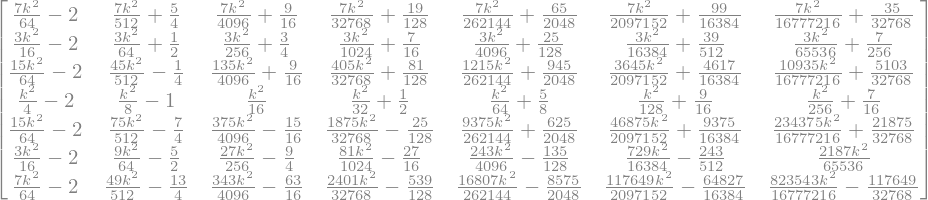

In [20]:
mat_colo = Matrix(nterms, nterms, lambda i, j: diff((eqs_colo[i]).lhs, c[j]))
mat_colo

In [21]:
vals_col = solve(det(mat_colo), k**2)

Poemos comparar con la solución analítica. En este caso
no tenemos garantía de que los valores propios están por
encima de los analíticos. Sin embargo, podemos ver
que los 4 primeros valores propios están bastante cerca.

In [22]:
sorted([re(N(sqrt(val), 4)) for val in vals_col])

In [23]:
[N(k * pi, 4) for k in range(1, nterms + 1)]